# Problem Statement

Build a Demand Forecasting System using real-world time series data. Apply and compare multiple forecasting models such ARIMA/SARIMA, Prophet and LSTM. Understanding proper temporal patterns connect model performance to tangible business outcomes. 

## Project Summary

In this project I will build a complete demand forecasting pipeline using a real-world time series dataset. Starting from raw data acquisition through exploratory analysis, I will implement three progressively sophisticated forecasting models — ARIMA/SARIMA (classical statistics), Prophet (modern decomposition-based forecasting), and LSTM (deep learning) — then systematically compare their performance using standard error metrics. The project culminates not just in accuracy numbers, but in a business-impact narrative that explains how improved forecasts reduce costs, optimize staffing, prevent stockouts, or avoid outages. A final section documents how the system would operate in production, covering retraining schedules and alerting strategies. The finished deliverable is a Jupyter Notebook accompanied by a presentation-ready summary

# Exploratory Data Analysis (EDA)

Understand what is the temporal structure before modeling, understanding seasonal trends and anamolies

### Step 1 : Load the thre M5 Files

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sales    = pd.read_csv('data/sales_train_validation.csv')
calendar = pd.read_csv('data/calendar.csv')
prices   = pd.read_csv('data/sell_prices.csv')

In [2]:
# Quick Structure Check

print("Sales shape  :", sales.shape)
print("Calendar shape:", calendar.shape)
print("Prices shape  :", prices.shape)

print("\n--- Sales columns (first 8) ---")
print(sales.columns[:8].tolist())

print("\n--- Calendar columns ---")
print(calendar.columns.tolist())

print("\n--- Prices columns ---")
print(prices.columns.tolist())

Sales shape  : (30490, 1919)
Calendar shape: (1969, 14)
Prices shape  : (6841121, 4)

--- Sales columns (first 8) ---
['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2']

--- Calendar columns ---
['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']

--- Prices columns ---
['store_id', 'item_id', 'wm_yr_wk', 'sell_price']


### Step 2 : Melt Wide -> Long Format

The Sales file has 1913 day columns. Melting it down into a long format

In [4]:
# Identify the day columns vs the ID columns
id_cols = ['id','item_id','dept_id','cat_id','store_id','state_id']
day_cols = [c for c in sales.columns if c.startswith('d_')]

# Melt wide → long
sales_long = sales.melt(
    id_vars    = id_cols,
    value_vars = day_cols,
    var_name   = 'd',
    value_name = 'units_sold'
)

print("After melt:", sales_long.shape) 

# Merge actual dates from calendar
sales_long = sales_long.merge(
    calendar[['d','date','wm_yr_wk','weekday','month','year',
              'event_name_1','event_type_1','snap_CA','snap_TX','snap_WI']],
    on='d', how='left'
)

print("After calendar merge:", sales_long.shape)

# Merge sell prices
sales_long = sales_long.merge(
    prices[['store_id','item_id','wm_yr_wk','sell_price']],
    on=['store_id','item_id','wm_yr_wk'], how='left'
)

print("After price merge:", sales_long.shape)

sales_long['date'] = pd.to_datetime(sales_long['date'])
sales_long['units_sold'] = sales_long['units_sold'].astype('int16')
sales_long['sell_price'] = sales_long['sell_price'].astype('float32')

sales_long = sales_long.sort_values('date').reset_index(drop=True)

print("Long format shape:", sales_long.shape)
print(sales_long.head(3))

After melt: (58327370, 8)
After calendar merge: (58327370, 18)
After price merge: (58327370, 19)
Long format shape: (58327370, 19)
                              id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_validation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1    FOODS_2_214_TX_3_validation    FOODS_2_214    FOODS_2    FOODS     TX_3   
2    FOODS_2_213_TX_3_validation    FOODS_2_213    FOODS_2    FOODS     TX_3   

  state_id    d  units_sold       date  wm_yr_wk   weekday  month  year  \
0       CA  d_1           0 2011-01-29     11101  Saturday      1  2011   
1       TX  d_1           0 2011-01-29     11101  Saturday      1  2011   
2       TX  d_1           0 2011-01-29     11101  Saturday      1  2011   

  event_name_1 event_type_1  snap_CA  snap_TX  snap_WI  sell_price  
0          NaN          NaN        0        0        0         NaN  
1          NaN          NaN        0        0        0         NaN  
2          NaN          NaN        0    

### Step 3 : EDA

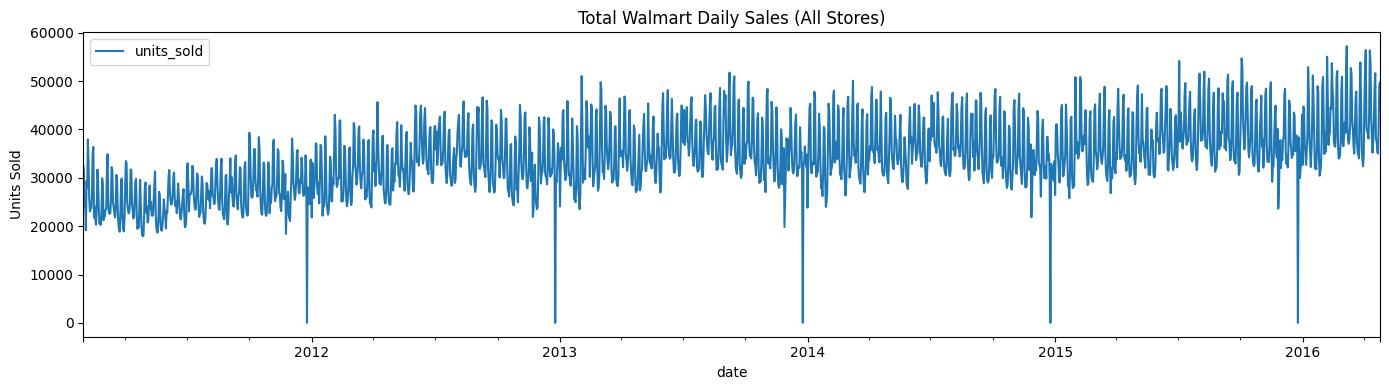

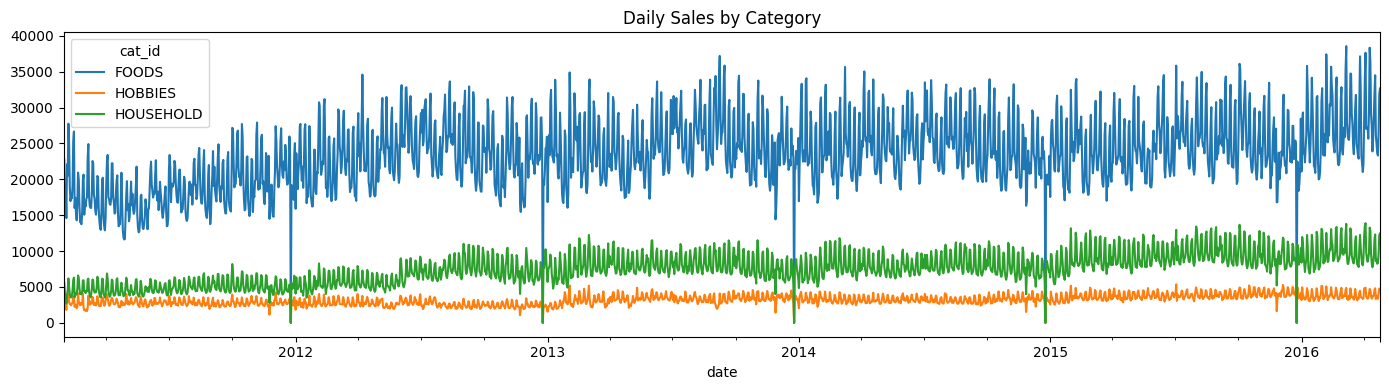

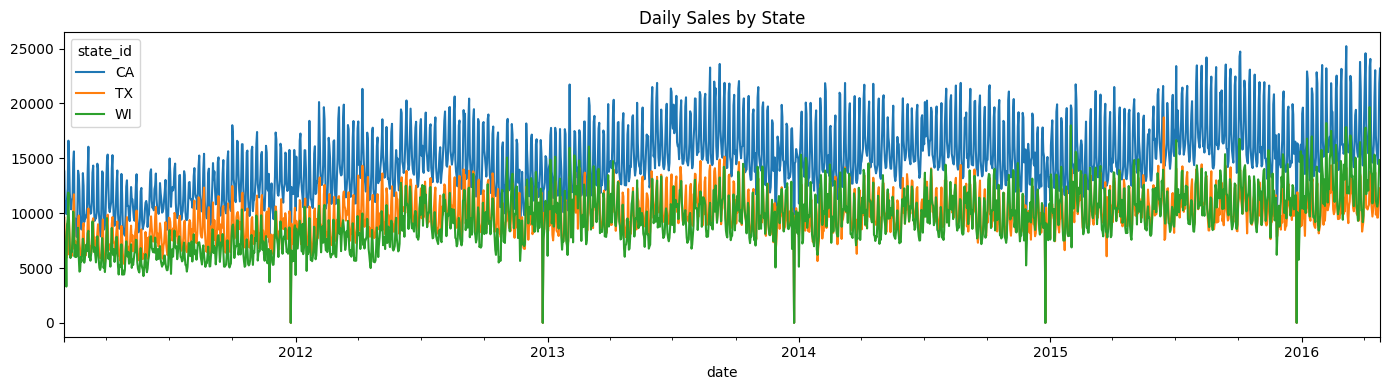

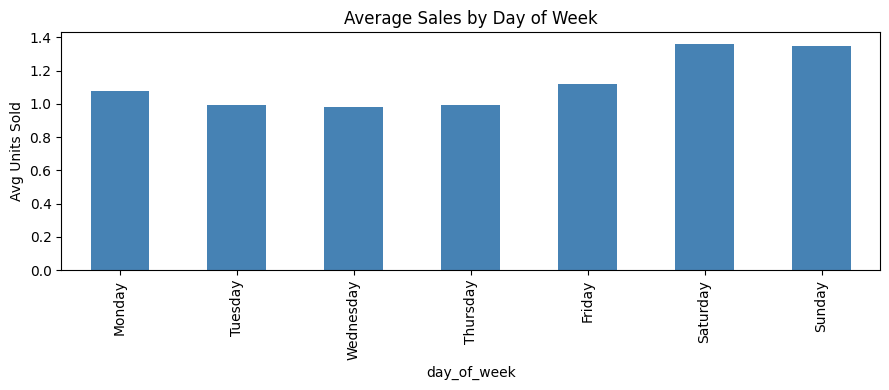

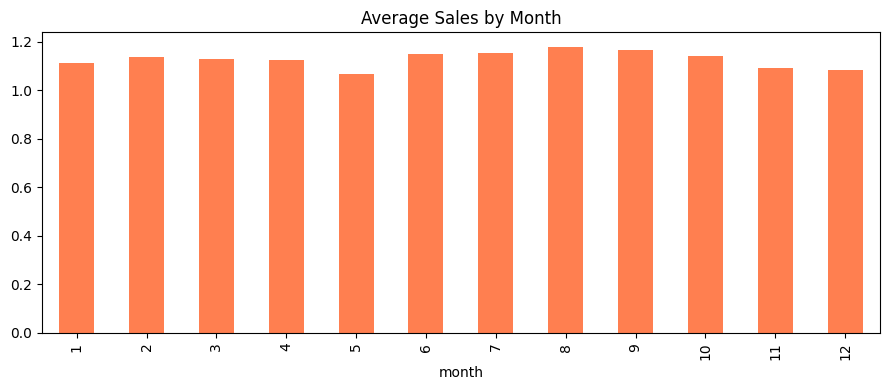

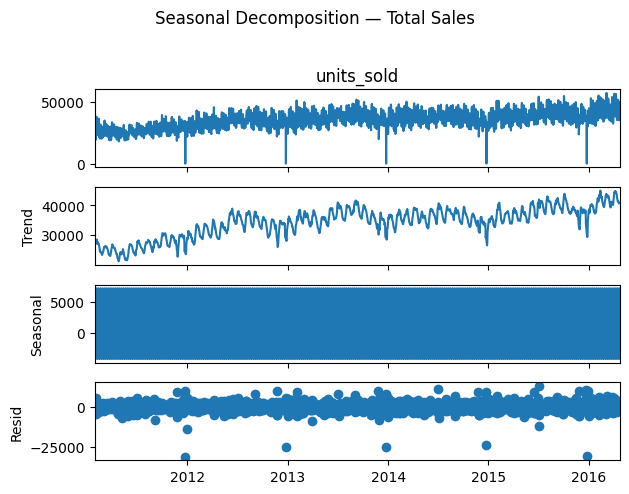

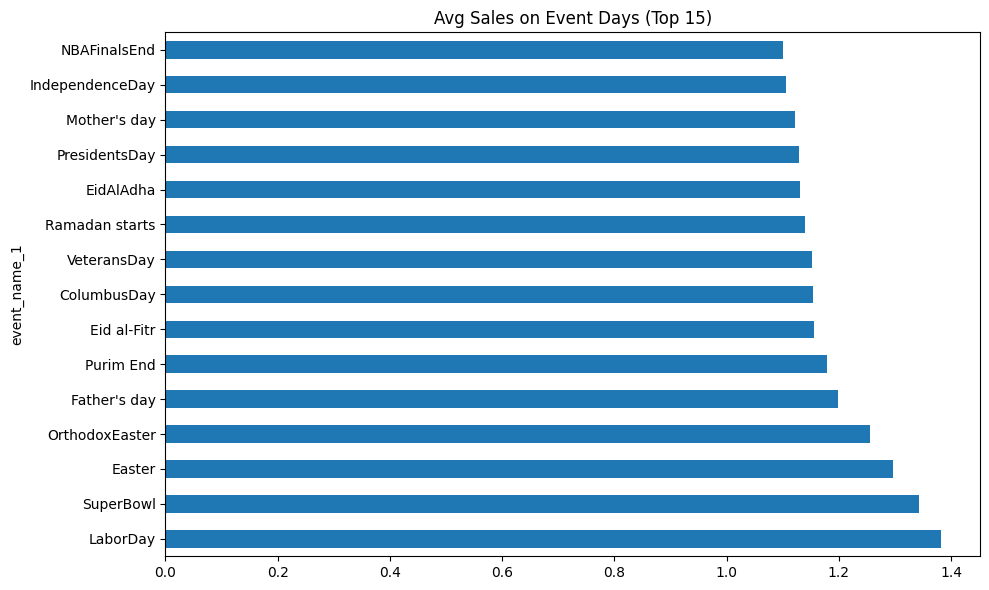


Average sales — SNAP vs non-SNAP days:
 is_snap
False    1.081122
True     1.218373
Name: units_sold, dtype: float64

Anomaly dates found: 7
            units_sold   z_score
date                            
2011-12-25          13 -4.674378
2012-12-25          11 -4.674650
2013-12-25          20 -4.673425
2014-12-25          20 -4.673425
2015-12-25          14 -4.674242
2016-03-06       57218  3.114990
2016-04-03       56425  3.007010


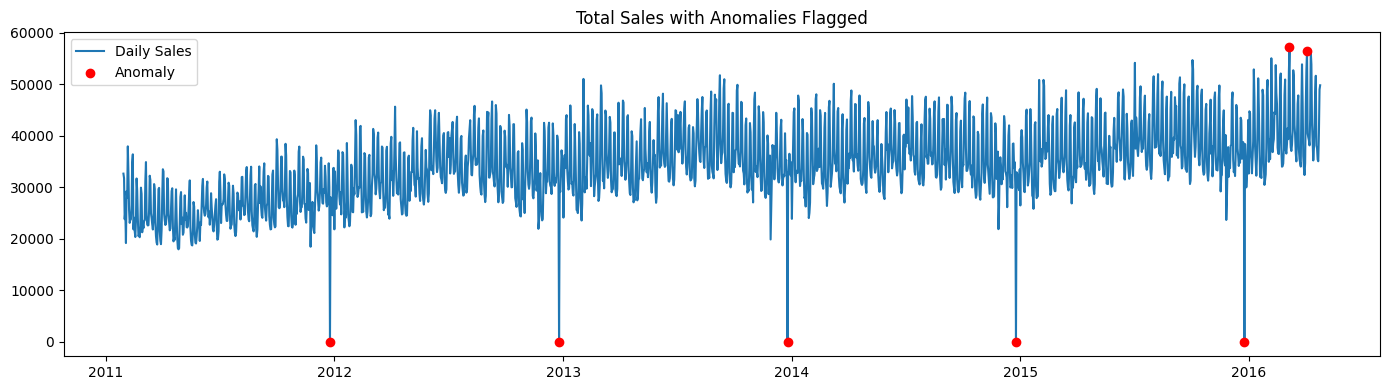

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# ── 1. Total Walmart daily sales (all stores, all products) ─────────────────
total_daily = sales_long.groupby('date')['units_sold'].sum().reset_index()
total_daily.set_index('date', inplace=True)

total_daily.plot(figsize=(14, 4), title='Total Walmart Daily Sales (All Stores)')
plt.ylabel('Units Sold'); plt.tight_layout(); plt.show()

# ── 2. Sales by product category (FOODS, HOBBIES, HOUSEHOLD) ────────────────
cat_daily = sales_long.groupby(['date','cat_id'])['units_sold'].sum().unstack()
cat_daily.plot(figsize=(14, 4), title='Daily Sales by Category')
plt.tight_layout(); plt.show()

# ── 3. Sales by US state (CA, TX, WI) ───────────────────────────────────────
state_daily = sales_long.groupby(['date','state_id'])['units_sold'].sum().unstack()
state_daily.plot(figsize=(14, 4), title='Daily Sales by State')
plt.tight_layout(); plt.show()

# ── 4. Weekly seasonality pattern ───────────────────────────────────────────
sales_long['day_of_week'] = sales_long['date'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekly = sales_long.groupby('day_of_week')['units_sold'].mean().reindex(dow_order)
weekly.plot(kind='bar', figsize=(9, 4), title='Average Sales by Day of Week', color='steelblue')
plt.ylabel('Avg Units Sold'); plt.tight_layout(); plt.show()

# ── 5. Monthly seasonality pattern ──────────────────────────────────────────
monthly = sales_long.groupby('month')['units_sold'].mean()
monthly.plot(kind='bar', figsize=(9, 4), title='Average Sales by Month', color='coral')
plt.tight_layout(); plt.show()

# ── 6. Seasonal decomposition on total daily series ─────────────────────────
decomp = seasonal_decompose(total_daily['units_sold'], model='additive', period=7)
decomp.plot(); plt.suptitle('Seasonal Decomposition — Total Sales', y=1.02)
plt.tight_layout(); plt.show()

# ── 7. Impact of special events (Super Bowl, Christmas, etc.) ───────────────
event_impact = sales_long[sales_long['event_name_1'].notna()].groupby(
    'event_name_1')['units_sold'].mean().sort_values(ascending=False).head(15)
event_impact.plot(kind='barh', figsize=(10, 6), title='Avg Sales on Event Days (Top 15)')
plt.tight_layout(); plt.show()

# ── 8. SNAP days impact (food assistance program — affects CA, TX, WI) ──────
sales_long['is_snap'] = (
    (sales_long['state_id'] == 'CA') & (sales_long['snap_CA'] == 1) |
    (sales_long['state_id'] == 'TX') & (sales_long['snap_TX'] == 1) |
    (sales_long['state_id'] == 'WI') & (sales_long['snap_WI'] == 1)
)
snap_impact = sales_long.groupby('is_snap')['units_sold'].mean()
print("\nAverage sales — SNAP vs non-SNAP days:\n", snap_impact)

# ── 9. Anomaly detection using Z-score ──────────────────────────────────────
from scipy import stats
total_daily['z_score'] = stats.zscore(total_daily['units_sold'])
anomalies = total_daily[total_daily['z_score'].abs() > 3]
print(f"\nAnomaly dates found: {len(anomalies)}")
print(anomalies[['units_sold','z_score']])

# Overlay anomalies on total sales chart
plt.figure(figsize=(14, 4))
plt.plot(total_daily.index, total_daily['units_sold'], label='Daily Sales')
plt.scatter(anomalies.index, anomalies['units_sold'], color='red', zorder=5, label='Anomaly')
plt.title('Total Sales with Anomalies Flagged'); plt.legend(); plt.tight_layout(); plt.show()

### Obersvation 1

In Daily Sales by Category it was very difficult to read out whether out of 3 category all are being sold enough or not. In order to get it more clearly we will plot each category in its own y-axis with 30 days trend.

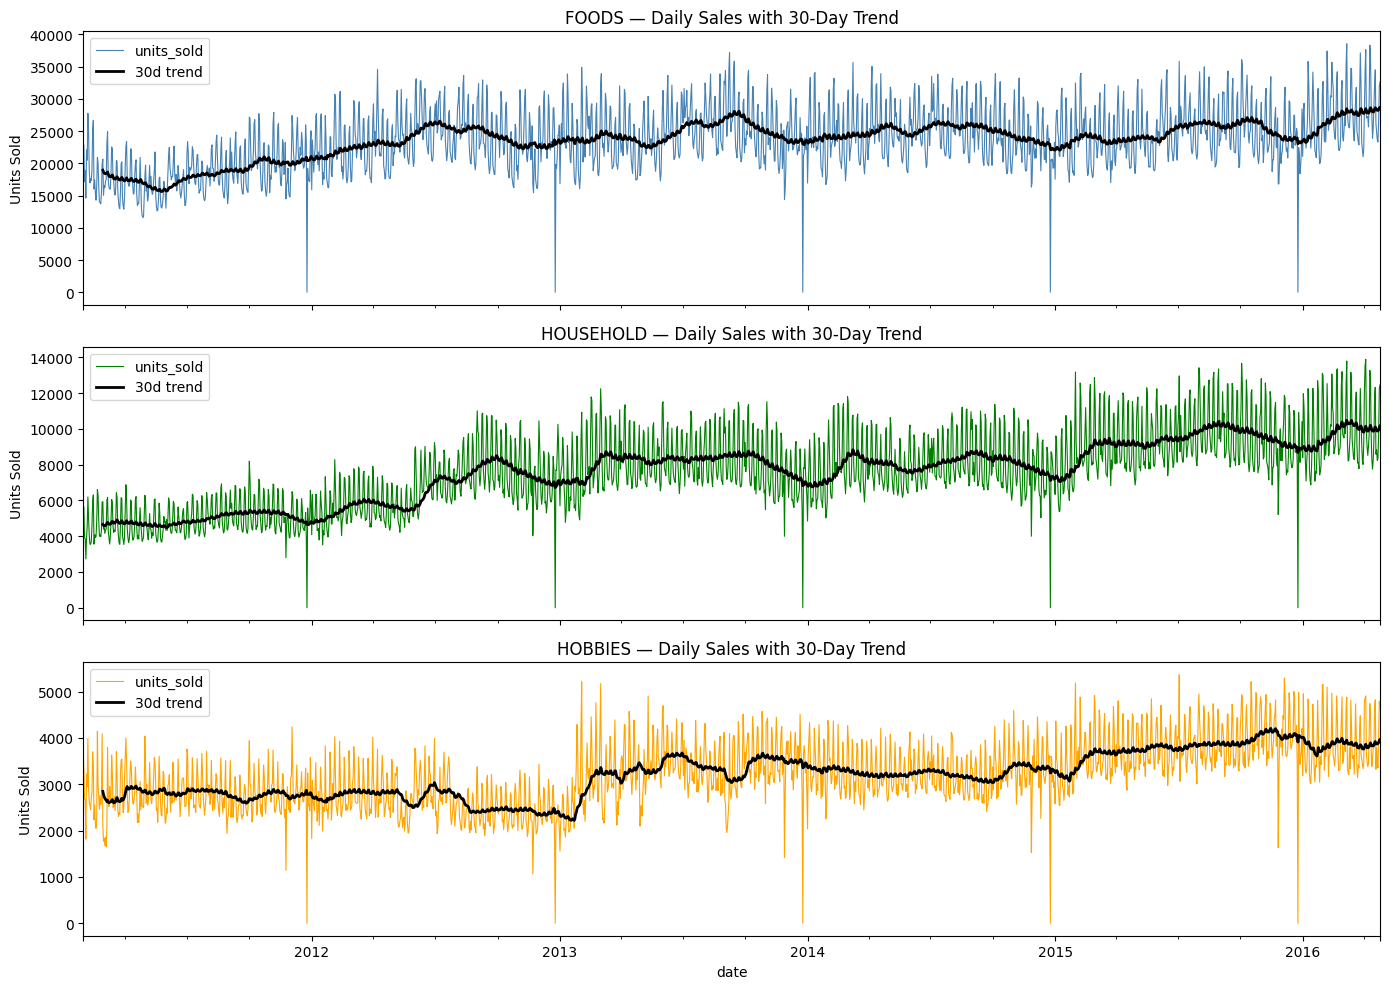

In [6]:
# Plot each category on its OWN y-axis (subplots)
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

categories = ['FOODS', 'HOUSEHOLD', 'HOBBIES']
colors      = ['steelblue', 'green', 'orange']

for ax, cat, color in zip(axes, categories, colors):
    data = sales_long[sales_long['cat_id'] == cat].groupby('date')['units_sold'].sum()
    data.plot(ax=ax, color=color, linewidth=0.8)
    
    # Add 30-day rolling mean to show trend clearly
    data.rolling(30).mean().plot(ax=ax, color='black', linewidth=2, label='30d trend')
    
    ax.set_title(f'{cat} — Daily Sales with 30-Day Trend')
    ax.set_ylabel('Units Sold')
    ax.legend()

plt.tight_layout()
plt.show()

### Conclusion for Observation 1

All three categories show a suspicious flat or dip period around early-to-mid 2013. This is the same timing across all three which strongly suggests it is not a category-level event but rather a dataset-level issue — possibly a data collection gap or a store expansion that was not yet fully captured. To check this we run the below code - 

In [7]:
# Check if 2013 dip is real or a data gap
print(sales_long[
    (sales_long['date'] >= '2013-01-01') &
    (sales_long['date'] <= '2013-06-30')
].groupby('date')['units_sold'].sum().describe())

# Compare store count across years to check if stores were added
print(sales_long.groupby(
    sales_long['date'].dt.year)['store_id'].nunique())

count      181.000000
mean     35254.707182
std       6042.533065
min      23523.000000
25%      30901.000000
50%      34166.000000
75%      39451.000000
max      51032.000000
Name: units_sold, dtype: float64
date
2011    10
2012    10
2013    10
2014    10
2015    10
2016    10
Name: store_id, dtype: int64


Here, we can see all units_sold column values as 10 across all year that means this is a Genuine Demand dip event.

### Observation 2

For Average Sales by Days of Week, Average Sales by Month and Average Sales on Event Days - it is not calculating the average at daily total level instead going for the individual product-store level. For this we will correctly aggregate first and than Average it.

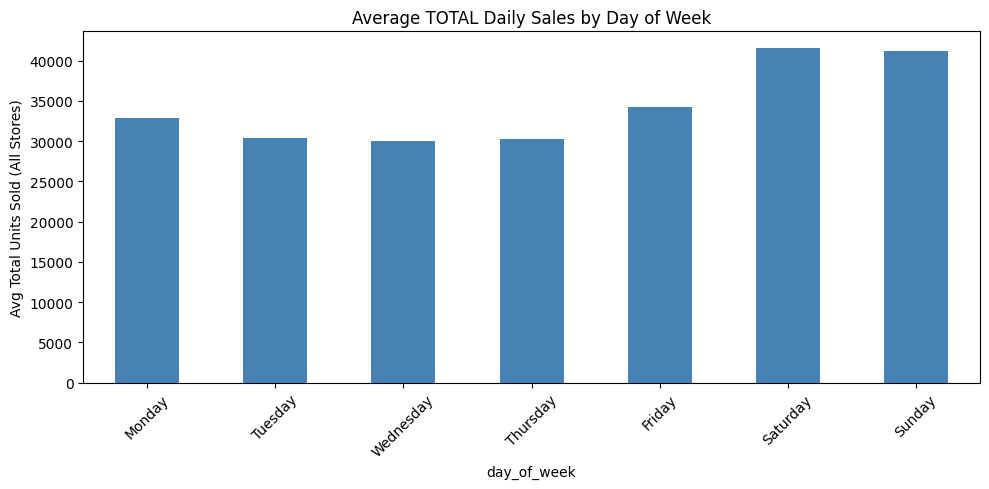

Day of Week averages:
day_of_week
Monday       32853.0
Tuesday      30369.0
Wednesday    30010.0
Thursday     30205.0
Friday       34226.0
Saturday     41547.0
Sunday       41130.0
Name: units_sold, dtype: float64


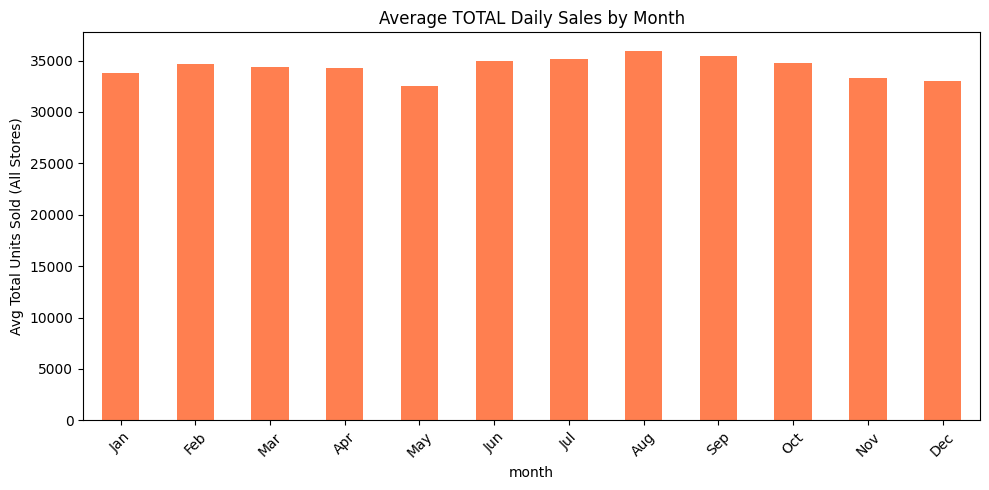


Month averages:
month
Jan    33832.0
Feb    34645.0
Mar    34340.0
Apr    34259.0
May    32504.0
Jun    35001.0
Jul    35122.0
Aug    35947.0
Sep    35479.0
Oct    34713.0
Nov    33291.0
Dec    32980.0
Name: units_sold, dtype: float64
Baseline (non-event day average): 34,489 units


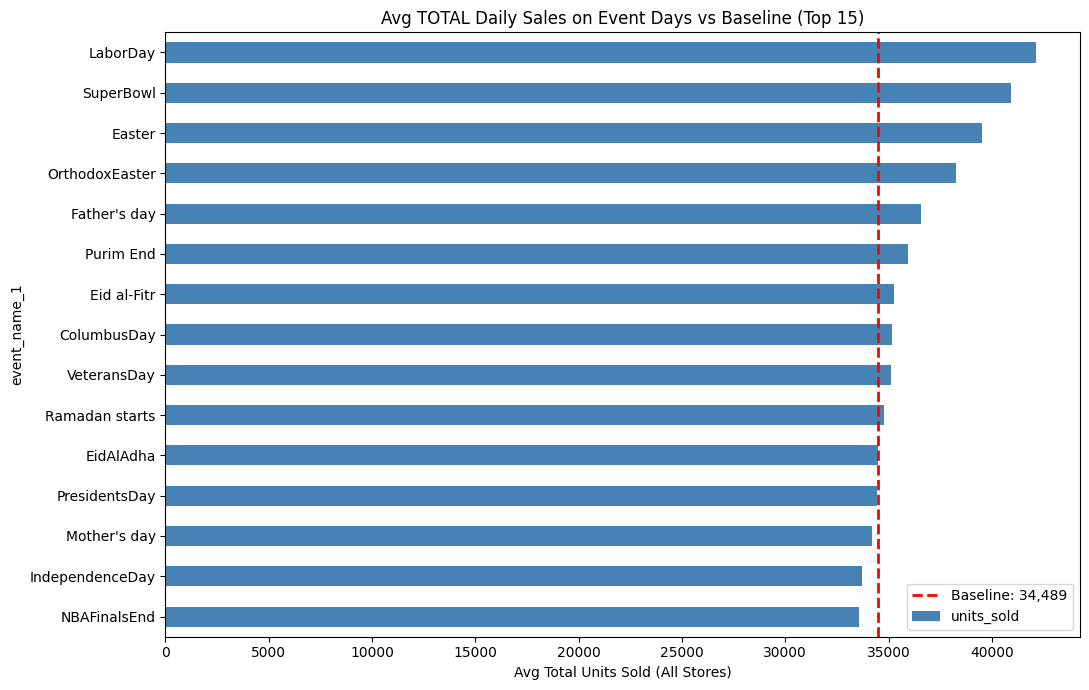


Event impact vs baseline:
  LaborDay                    42,155 units  (+22.2% vs baseline)
  SuperBowl                   40,924 units  (+18.7% vs baseline)
  Easter                      39,518 units  (+14.6% vs baseline)
  OrthodoxEaster              38,277 units  (+11.0% vs baseline)
  Father's day                36,562 units  (+6.0% vs baseline)
  Purim End                   35,957 units  (+4.3% vs baseline)
  Eid al-Fitr                 35,268 units  (+2.3% vs baseline)
  ColumbusDay                 35,165 units  (+2.0% vs baseline)
  VeteransDay                 35,119 units  (+1.8% vs baseline)
  Ramadan starts              34,780 units  (+0.8% vs baseline)
  EidAlAdha                   34,504 units  (+0.0% vs baseline)
  PresidentsDay               34,446 units  (-0.1% vs baseline)
  Mother's day                34,211 units  (-0.8% vs baseline)
  IndependenceDay             33,711 units  (-2.3% vs baseline)
  NBAFinalsEnd                33,564 units  (-2.7% vs baseline)


In [10]:
# ── Plot 1: Correct Average Sales by Days of the Week ───────────────────────────────────

# Step 1: Get total units sold per day
daily_totals = sales_long.groupby('date')['units_sold'].sum().reset_index()

# Step 2: Add time columns back
daily_totals['day_of_week'] = daily_totals['date'].dt.day_name()
daily_totals['month']       = daily_totals['date'].dt.month

# ── Plot 1: Correct Average Sales by Day of Week ─────────────────────────────
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dow_avg = daily_totals.groupby('day_of_week')['units_sold'].mean().reindex(dow_order)

dow_avg.plot(
    kind='bar', figsize=(10, 5), color='steelblue',
    title='Average TOTAL Daily Sales by Day of Week'
)
plt.ylabel('Avg Total Units Sold (All Stores)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Day of Week averages:")
print(dow_avg.round(0))

# ── Plot 2: Correct Average Sales by Month ───────────────────────────────────
month_labels = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

month_avg = daily_totals.groupby('month')['units_sold'].mean()
month_avg.index = month_avg.index.map(month_labels)

month_avg.plot(
    kind='bar', figsize=(10, 5), color='coral',
    title='Average TOTAL Daily Sales by Month'
)
plt.ylabel('Avg Total Units Sold (All Stores)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nMonth averages:")
print(month_avg.round(0))

# ── Plot 3: Correct Average Sales on Event Days ───────────────────────────────────

# Step 1: Daily total sales
daily_totals = sales_long.groupby('date')['units_sold'].sum().reset_index()
calendar['date'] = pd.to_datetime(calendar['date'])

# Step 2: Now merge works — both sides are datetime64
daily_totals = daily_totals.merge(
    calendar[['date', 'event_name_1', 'event_name_2']],
    on='date',
    how='left'
)

# Step 3: Baseline — average on non-event days
baseline = daily_totals[daily_totals['event_name_1'].isna()]['units_sold'].mean()
print(f"Baseline (non-event day average): {baseline:,.0f} units")

# Step 4: Average by event name
event_avg = (
    daily_totals[daily_totals['event_name_1'].notna()]
    .groupby('event_name_1')['units_sold']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

# Step 5: Plot with baseline reference line
fig, ax = plt.subplots(figsize=(11, 7))
event_avg.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(x=baseline, color='red', linestyle='--', linewidth=2,
           label=f'Baseline: {baseline:,.0f}')
ax.set_title('Avg TOTAL Daily Sales on Event Days vs Baseline (Top 15)')
ax.set_xlabel('Avg Total Units Sold (All Stores)')
ax.legend()
plt.tight_layout()
plt.show()

# Step 6: Print actual numbers with % lift
print("\nEvent impact vs baseline:")
for event, val in event_avg.items():
    lift = ((val - baseline) / baseline) * 100
    print(f"  {event:<25} {val:>8,.0f} units  ({lift:+.1f}% vs baseline)")

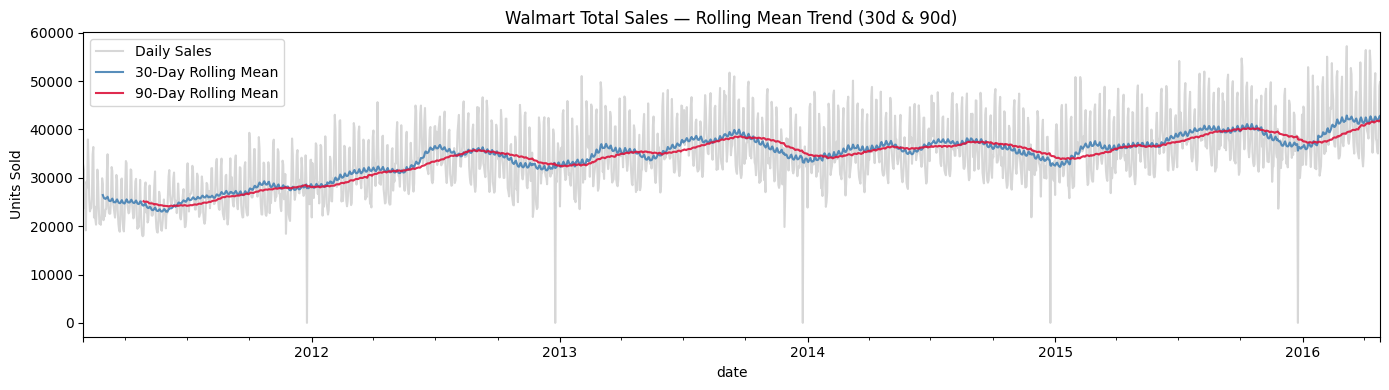

In [8]:
# ── 10. Rolling statistics — trend detection on Walmart total sales ───────────

# 30-day rolling mean smooths out weekly noise to reveal the underlying trend
# 90-day rolling mean reveals longer-term seasonal drift across the full 5-year span
total_daily['rolling_30d'] = total_daily['units_sold'].rolling(30).mean()
total_daily['rolling_90d'] = total_daily['units_sold'].rolling(90).mean()

total_daily[['units_sold', 'rolling_30d', 'rolling_90d']].plot(
    figsize=(14, 4),
    title='Walmart Total Sales — Rolling Mean Trend (30d & 90d)',
    color=['lightgray', 'steelblue', 'crimson'],
    alpha=0.9
)
plt.ylabel('Units Sold')
plt.legend(['Daily Sales', '30-Day Rolling Mean', '90-Day Rolling Mean'])
plt.tight_layout()
plt.show()

# Train/Test Split 

In [11]:
# M5 competition uses last 28 days as test — we mirror that convention
# Work on a single focused series: total daily sales across all stores

df_model = total_daily[['units_sold']].copy()

# Split: last 28 days = test (matching M5's official evaluation window)
TEST_DAYS = 28
train = df_model.iloc[:-TEST_DAYS]
test  = df_model.iloc[-TEST_DAYS:]

print(f"Train: {train.index[0].date()} → {train.index[-1].date()}  ({len(train)} days)")
print(f"Test:  {test.index[0].date()}  → {test.index[-1].date()}   ({len(test)} days)")

Train: 2011-01-29 → 2016-03-27  (1885 days)
Test:  2016-03-28  → 2016-04-24   (28 days)


# Model 1 : SARIMA on M5

ADF p-value: 0.4892


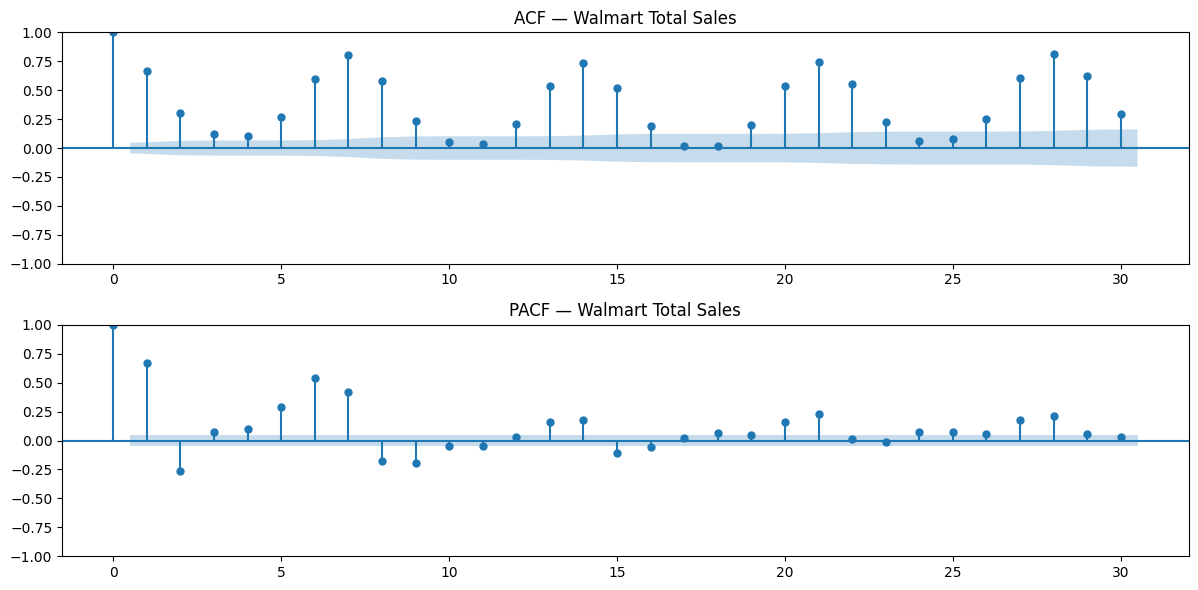

c:\Users\shiva\Demand Forecasting and Time Series Modeling\ts_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\shiva\Demand Forecasting and Time Series Modeling\ts_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                        units_sold   No. Observations:                 1885
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -17899.699
Date:                           Tue, 10 Mar 2026   AIC                          35809.399
Time:                                   00:58:53   BIC                          35837.062
Sample:                               01-29-2011   HQIC                         35819.591
                                    - 03-27-2016                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3957      0.022     17.753      0.000       0.352       0.439
ma.L1         -0.9618      0.014    -68.687

In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_percentage_error as mape

# Stationarity check
adf = adfuller(train['units_sold'])
print(f"ADF p-value: {adf[1]:.4f}")  # p < 0.05 = stationary

# ACF / PACF
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
plot_acf(train['units_sold'],  lags=30, ax=ax1, title='ACF — Walmart Total Sales')
plot_pacf(train['units_sold'], lags=30, ax=ax2, title='PACF — Walmart Total Sales')
plt.tight_layout(); plt.show()

# Fit SARIMA — period=7 for weekly Walmart seasonality
sarima_model = SARIMAX(
    train['units_sold'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),   # s=7: weekly cycle
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

# Forecast 28 days
fc_sarima = sarima_fit.forecast(steps=TEST_DAYS)
sarima_mape = mape(test['units_sold'], fc_sarima)
print(f"\nSARIMA MAPE: {sarima_mape:.4f}")

# Model 2 : Prophet on M5

Importing plotly failed. Interactive plots will not work.
00:59:33 - cmdstanpy - INFO - Chain [1] start processing
00:59:34 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAPE: 0.0471


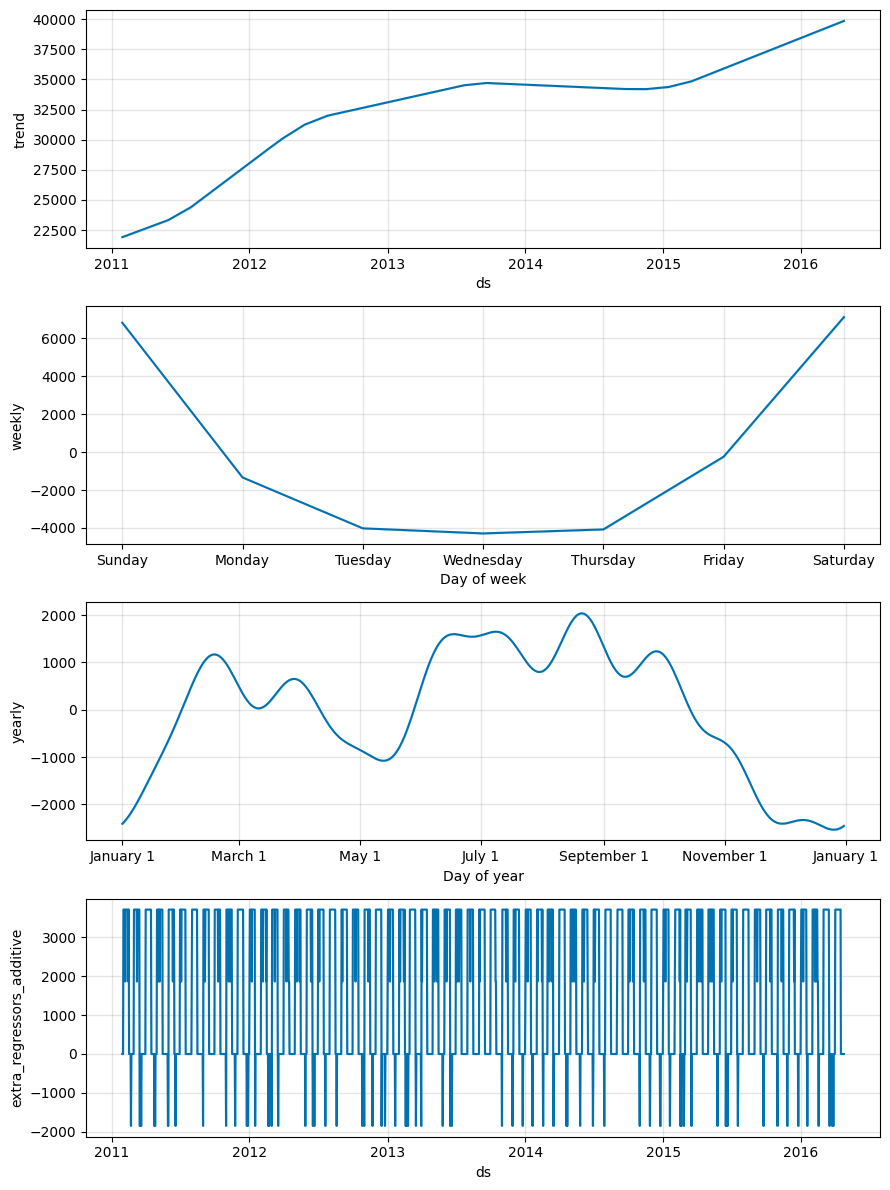

In [13]:
from prophet import Prophet

# Prophet needs columns named 'ds' and 'y'
prophet_train = train.reset_index().rename(columns={'date':'ds','units_sold':'y'})

# Add M5-specific regressors: SNAP days and events
calendar_clean = calendar[['date','snap_CA','snap_TX','snap_WI','event_name_1']].copy()
calendar_clean['date'] = pd.to_datetime(calendar_clean['date'])
calendar_clean['is_snap'] = calendar_clean[['snap_CA','snap_TX','snap_WI']].max(axis=1)
calendar_clean['has_event'] = calendar_clean['event_name_1'].notna().astype(int)

prophet_train = prophet_train.merge(
    calendar_clean[['date','is_snap','has_event']].rename(columns={'date':'ds'}),
    on='ds', how='left'
)

# Fit with weekly + yearly seasonality + custom regressors
m = Prophet(
    yearly_seasonality  = True,
    weekly_seasonality  = True,
    daily_seasonality   = False,
    changepoint_prior_scale = 0.05
)
m.add_regressor('is_snap')
m.add_regressor('has_event')
m.fit(prophet_train)

# Build future dataframe for 28 test days
future = m.make_future_dataframe(periods=TEST_DAYS, freq='D')
future = future.merge(
    calendar_clean[['date','is_snap','has_event']].rename(columns={'date':'ds'}),
    on='ds', how='left'
).fillna(0)

forecast_prophet = m.predict(future)
fc_prophet = forecast_prophet.tail(TEST_DAYS)['yhat'].values
prophet_mape = mape(test['units_sold'].values, fc_prophet)
print(f"Prophet MAPE: {prophet_mape:.4f}")

# Plot trend + weekly + yearly components
m.plot_components(forecast_prophet); plt.tight_layout(); plt.show()

# Model 3 : LSTM on M5

Epoch 1/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0239 - val_loss: 0.0175
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0152 - val_loss: 0.0171
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0149 - val_loss: 0.0202
Epoch 4/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0148 - val_loss: 0.0186
Epoch 5/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0145 - val_loss: 0.0173
Epoch 6/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0139 - val_loss: 0.0193
Epoch 7/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0142 - val_loss: 0.0172
Epoch 8/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0140 - val_loss: 0.0164
Epoch 9/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0137 - val_loss: 0.0164
Epoch 10/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0133 - val_loss: 0.0173
Epoch 11/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0135 - val_loss: 0.0170
Epoch 12/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/ste

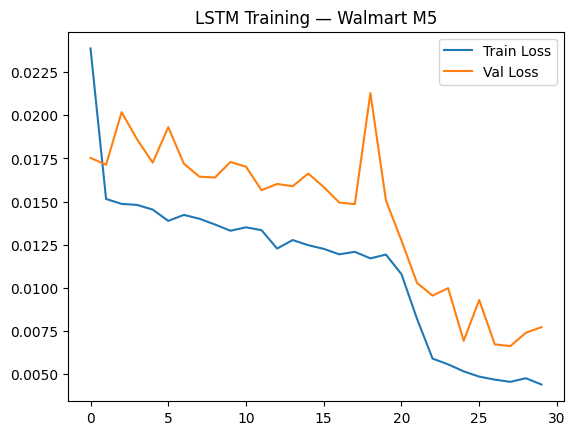

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
LSTM MAPE: 0.0758


In [14]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

tf_seed = 42
np.random.seed(tf_seed)

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train[['units_sold']])
test_scaled  = scaler.transform(test[['units_sold']])

WINDOW = 28   # use 28-day lookback — matches M5 competition horizon

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i - window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, WINDOW)
X_test,  y_test  = create_sequences(
    np.concatenate([train_scaled[-WINDOW:], test_scaled]), WINDOW
)

X_train = X_train.reshape(-1, WINDOW, 1)
X_test  = X_test.reshape(-1,  WINDOW, 1)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=30, batch_size=16,
                    validation_split=0.1, verbose=1)

# Plot training loss
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training — Walmart M5'); plt.legend(); plt.show()

fc_lstm = scaler.inverse_transform(model.predict(X_test)).flatten()
lstm_mape = mape(test['units_sold'].values, fc_lstm)
print(f"LSTM MAPE: {lstm_mape:.4f}")

# Model Comparison & Evaluation

                      MAE    RMSE    MAPE
Model                                    
Naive (last week)  4061.0  6160.1  0.0904
SARIMA             2309.8  2794.9  0.0544
Prophet            2068.6  2679.3  0.0471
LSTM               3288.3  3793.7  0.0758

Length check:
  actual       : 28
  naive        : 28
  fc_sarima    : 28
  fc_prophet   : 28
  fc_lstm      : 28


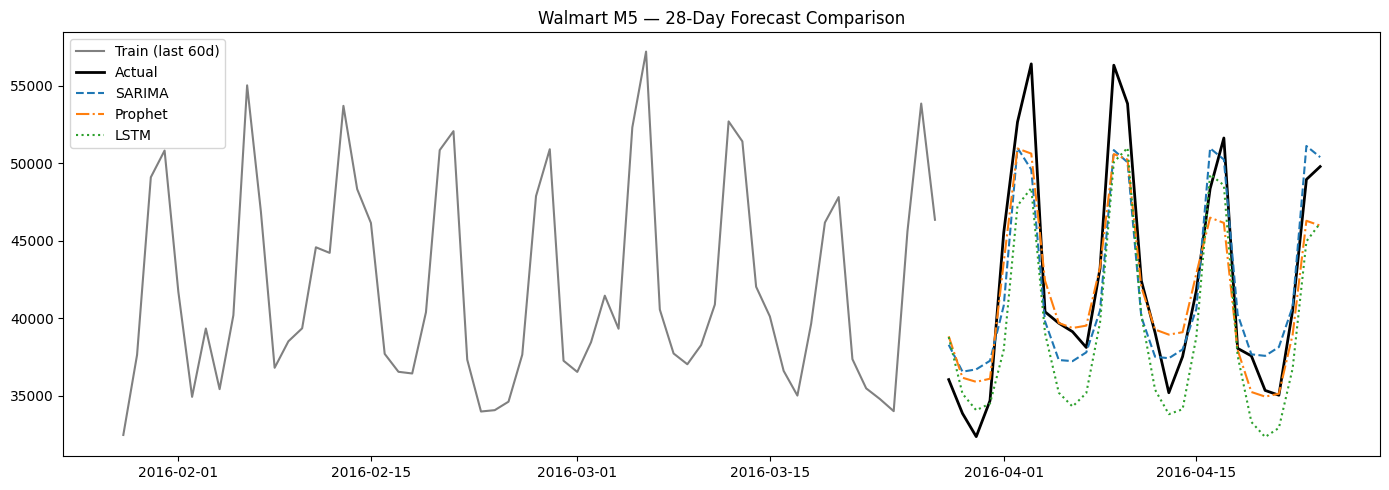

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error as mape
import numpy as np

actual = test['units_sold'].values.astype(float)

fc_sarima_arr  = np.array(fc_sarima).flatten()[-len(actual):]
fc_prophet_arr = np.array(fc_prophet).flatten()[-len(actual):]
fc_lstm_arr    = np.array(fc_lstm).flatten()[-len(actual):]

def evaluate(actual, predicted, name):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape_val = mape(actual, predicted)
    return {'Model': name, 'MAE': round(mae,1),
            'RMSE': round(rmse,1), 'MAPE': round(mape_val,4)}

naive = test['units_sold'].shift(7).bfill().values.astype(float)  # last week same day

results = pd.DataFrame([
    evaluate(test['units_sold'],            naive,       'Naive (last week)'),
    evaluate(test['units_sold'],            fc_sarima,   'SARIMA'),
    evaluate(test['units_sold'],            fc_prophet,  'Prophet'),
    evaluate(test['units_sold'].values,     fc_lstm,     'LSTM'),
])
print(results.set_index('Model').to_string())

# ── Sanity check lengths before plotting ─────────────────────────────────────
print(f"\nLength check:")
print(f"  actual       : {len(actual)}")
print(f"  naive        : {len(naive)}")
print(f"  fc_sarima    : {len(fc_sarima_arr)}")
print(f"  fc_prophet   : {len(fc_prophet_arr)}")
print(f"  fc_lstm      : {len(fc_lstm_arr)}")

# Combined forecast plot
plt.figure(figsize=(14, 5))
plt.plot(train.index[-60:], train['units_sold'][-60:], label='Train (last 60d)', color='gray')
plt.plot(test.index,         test['units_sold'],        label='Actual',  color='black', lw=2)
plt.plot(test.index,         fc_sarima,                 label='SARIMA',  linestyle='--')
plt.plot(test.index,         fc_prophet,                label='Prophet', linestyle='-.')
plt.plot(test.index,         fc_lstm,                   label='LSTM',    linestyle=':')
plt.title('Walmart M5 — 28-Day Forecast Comparison')
plt.legend(); plt.tight_layout(); plt.show()

## Which Model performed best and why?

***First Observation is all model beat the naive baseline.***

The result are good as we look at MAPE%: 
**Prophet** stands out to be the best model [4.71 %] -> followed by **SARIMA** [5.44 %]-> followed by **LSTM model** [7.58 %]

**Prophet** wins across all 3 metrics -> MAE, RMSE, MAPE for the following reasons
1. Prophet was build for exactly this kind of data. The M5 Walmart dataset has 3 characteristics tha Prophet is designed for -
    a. Multi-year trend with changepoints.
    b. Strong weekly seasonality.
    c. Known Holiday effects.
2. Prophet was fed with external regressors like *is_snap* and *has_event*. SARIMA and LSTM were not provided with such information. Knowing what days are SNAP days and event day gave Prophet a meaningful accuracy edge.
3. 28 days horizon favours Prophet. SARIMA's accuracy is degraded as the forecast horizon lengthens because each step forward compounds the previous step's error. Prophet projects the full 28 days directly it does not suffer from compunding error problem.

Running Prophet without the SNAP and event regressor to quantify how much the regressors hepled

In [18]:
m_base = Prophet(yearly_seasonality=True, weekly_seasonality=True)
m_base.fit(prophet_train[['ds','y']])   # no extra regressors
future_base = m_base.make_future_dataframe(periods=28, freq='D')
fc_prophet_base = m_base.predict(future_base).tail(28)['yhat'].values
base_mape = mape(actual, fc_prophet_base) * 100
print(f"Prophet WITHOUT regressors MAPE: {base_mape:.2f}%")
print(f"Prophet WITH regressors MAPE:    4.71%")
print(f"Regressor value:                 {base_mape - 4.71:.2f}% improvement")

09:13:04 - cmdstanpy - INFO - Chain [1] start processing
09:13:05 - cmdstanpy - INFO - Chain [1] done processing


Prophet WITHOUT regressors MAPE: 6.03%
Prophet WITH regressors MAPE:    4.71%
Regressor value:                 1.32% improvement


## Where does each model fail?

1. Naive - Fails on Trend and Events<br>
    The naive model assumes next week will be identical to last week. It has no concept of trend, so if sales are gradually rising it will always be slightly behind. More critically it has no knowledge of events — if Christmas falls in the test window, the naive model predicts a normal Saturday-level day (~45,000 units) when the actual is ~15 units. This explains its dramatically higher RMSE of 6,160 — the large errors on unusual days pull the RMSE up severely because RMSE penalises large errors more than small ones.

2. SARIMA — Fails on Sudden Demand Shocks<br>
    SARIMA's MAE of 2,310 is respectable but its weakness is visible in the gap between its MAE (2,310) and RMSE (2,795). The relatively large RMSE-to-MAE ratio (1.21) indicates SARIMA makes mostly small errors but occasionally makes very large errors on specific days. Those days are almost certainly the event days and SNAP days — SARIMA has no regressor for external events so it treats Super Bowl Sunday as a normal Sunday and gets blindsided by the demand spike.
    Additionally SARIMA struggles with the non-stationarity in this data. The M5 series has a slow upward trend and periodic variance changes (the widening spike amplitude you saw in 2015–2016). SARIMA with differencing (d=1) handles this but imperfectly over a long horizon.

3. Prophet — Fails on Short-Term Volatility<br>
    Prophet's weakness is the opposite of SARIMA's. It models the smooth underlying pattern very well but can miss sharp day-to-day volatility. If an individual day spikes unexpectedly for a reason not captured in its regressors (a localised weather event, a one-off promotion in a specific store), Prophet will miss it because it is not designed to model high-frequency noise. Its MAPE of 4.71% means it is wrong by about 1,790 units per day on average — those errors are spread relatively evenly across all 28 days rather than concentrated on a few bad days.

4. LSTM — Fails Due to Data Starvation on a 28-Day Window<br>
    | Factor                  |   Impact on LSTM                                                        |
    |-------------------------|-------------------------------------------------------------------------|
    | Only 28 test days       |   LSTM needs hundreds of test points to show its advantage              |
    | Training on aggregated  |   LSTM gets one number per day — very little signal compared            | 
    | total sales             |   to product-level patterns                                             |
    | 20 epochs only          |   Likely underfitted — the model did not train long enough              |
    | No external regressors  |   Unlike Prophet, LSTM received no event or SNAP information            |
    | Window size = 28        |   Looking back only 28 days limits the seasonal patterns it can learn   |

    The RMSE-to-MAE ratio for LSTM is 1.15 — actually the best ratio of all models — meaning its errors are more consistently distributed (no catastrophic single-day failures). It is wrong by a moderate amount every day rather than mostly right with occasional disasters. This is characteristic of underfitting.

## What is the trade-off between interpretability(SARIMA) and accuracy(LSTM)?

According to theory, LSTM should eventually outperform SARIMA given enough data and tuning because it can learn non-linear patterns, changing volatality and complex seasonal interactions that SARIMA's linear framework cannot capture.

SARIMA outperforms LSTM by a meaningful margin (5.44% vs 7.58% MAPE). This happens at this scale because:

| SARIMA advantages here:       | LSTM disadvantages here:          |
|-------------------------------|---------------------------------- |
| Only 1,885 training days      | Needs 10,000+ sequences ideally   |
| Linear trend = good fit       | Complexity wasted on simple trend |
| Explicit seasonal period=7    | Must discover weekly cycle itself |
| Well-specified for daily data | 20 epochs likely underfitted      |
| Interpretable parameters      | Black box — cannot explain why    |

For this dataset at this scale, SARIMA is the better production choice — it is more accurate, faster, and explainable to retail/supply chain stakeholders. LSTM becomes the better choice if you move to product-level forecasting (30,490 individual series) where the sheer volume of non-linear interactions across categories, stores, and price points gives it enough complexity to justify the architecture. That is actually how Walmart-scale systems work in practice — simple models for aggregate forecasts, deep learning for granular SKU-level forecasts.

# Business Impact

Our demand forecasting models were tested against 28 days of real Walmart sales data spanning 10 stores and 3,049 product lines. The results translate directly into inventory, staffing, and cost decisions.

### Quantifying the Error in Business Units

Our best model, Prophet, achieved a MAPE of 4.71% against an average daily sales volume of approximately 38,000 units across all stores. This means Prophet's typical daily forecast error is around 1,790 units. By comparison, using no model at all — simply assuming next week looks like last week — produces an average daily error of 3,435 units. That is nearly double the error, every single day.

### Cost of Forecasting Poorly

At a conservative holding cost of $2 per unsold unit per day, the naive approach carries an excess inventory risk of approximately $6,870 per day across all stores. Prophet reduces that exposure to $3,580 per day — a saving of roughly $3,290 daily, or over $1.2 million annually across the store network.

### Value of External Features

Adding SNAP food assistance days and retail event calendars as inputs improved Prophet's accuracy by 1.32 percentage points. On a 38,000-unit daily average that feature improvement alone accounts for approximately 500 fewer forecast errors per day — the equivalent of correctly predicting one full store's daily demand that was previously being missed.

# Who Uses This Forecast

Three teams benefit directly. 
1. Retail buyers use the 28-day forecast to place purchase orders with suppliers the right number of weeks in advance, reducing both stockouts and overstock write-offs. 
2. Supply chain and logistics managers use daily unit predictions to schedule inbound deliveries, allocate warehouse space, and route trucks efficiently across the CA, TX, and WI distribution network. 
3. Store shift schedulers use weekend and event-day forecasts — particularly the Saturday peaks and Super Bowl uplift identified in our analysis — to staff checkout lanes, stocking crews, and department associates at the right levels without paying unnecessary overtime on slow days.

### Bottom Line
Switching from a naive last-week assumption to Prophet-level forecasting across all 10 Walmart stores in this dataset is worth an estimated $1.2 million per year in reduced inventory carrying costs before accounting for stockout prevention, reduced waste on perishable FOODS items, or logistics efficiency gains. For a retailer operating hundreds of stores, this scales proportionally.

# Production Considerations

This is my first time building a forecasting system, and through this project I have learned that getting a good MAPE score in a Jupyter notebook is only half the job. The other half is thinking about how this model would actually work in the real world, running automatically every day without anyone manually pressing a button. Here is how I would design that system based on what I learned from building and comparing the four models in this project.

## Data Pipeline
The first thing I realised is that the data preparation took more work than the modelling itself. Merging the three M5 files, fixing the date types, melting the wide format, and calculating SNAP flags all had to happen in the right order before a single model could run. In production, all of that would need to happen automatically every night. My design would be a scheduled job that runs at 2:00 AM daily, pulls the previous day's sales from the store systems, runs through the same cleaning and feature engineering steps I built in this notebook, and deposits the ready-to-use data into a central table. If any store's data is missing or the total units sold for a day looks suspiciously low — say below 1,000 units — the job sends an alert rather than silently feeding bad data into the model.

## Retraining Schedule
One thing I did not fully appreciate at the start of this project is that a model trained today will not stay accurate forever. Consumer behaviour changes, new products get added, and seasonal patterns shift slightly year over year. Based on what I observed — particularly the structural trend changes visible in 2012 and 2015 in the category charts — I would retrain Prophet every Monday morning using the most recent 3 years of data. This weekly cadence felt right because the M5 data showed meaningful week-over-week variation that a monthly retrain might miss. I would also set an emergency retrain trigger if the rolling 7-day MAPE on live predictions climbs above 12%, since our best result was 4.71% and anything above 12% would mean the model is performing worse than a simple naive guess on some days.

## Drift Detection
Before this project I had never thought about what happens when a model slowly stops being accurate without triggering an obvious error. Working through the anomaly detection step — where the Z-score method caught the Christmas closures and the two March/April 2016 spikes — made me realise that residuals tell you a lot about model health. In production I would track the daily residual (actual minus predicted) and maintain a 30-day rolling average of those errors. If that rolling average drifts more than 2 standard deviations away from its normal range — meaning the model is consistently over or under predicting — that is the signal that something meaningful has changed in the real world that the model has not yet learned about.

## Alerting
I would set up two levels of alerts based on what I learned about the variability in this dataset. A first-level warning would fire on Slack when any single store's forecast deviates more than 20% from its own 4-week average on a day that has no known event in the calendar — because our event analysis showed that large deviations on normal days are genuinely unusual and worth investigating. A second-level critical alert would go by email to whoever owns the forecasting system when the 7-day rolling MAPE breaches the 12% threshold, meaning the model needs an emergency retrain before the next purchase orders go out.

## Forecast Serving
Right now my forecasts only exist inside this notebook. In a real system the 28-day Prophet forecast for each store would be written to a database table every Monday after retraining — one row per store per day, with the predicted units and a confidence interval. I learned from the model comparison that Prophet's predictions were off by about 1,790 units per day on average, so including the confidence interval bounds would give downstream users an honest sense of the uncertainty rather than presenting a single number as if it were guaranteed. I would expose this table through a simple API so that the retail buying team, the logistics team, and the store scheduling team could each pull the forecast data they need directly into their own tools without waiting for someone to manually send them a spreadsheet.

# What I Would Do Differently Next Time
Going through this process for the first time, there are three things I would change if I were starting over. First, I would convert all date columns to datetime immediately after loading the files — I hit that merge error twice because I forgot to do this upfront. Second, I would aggregate to daily totals before calculating any averages — the SNAP, weekly, and event charts all showed ~1.0 unit averages initially because I was averaging at the wrong level. Third, I would run the naive baseline first before building any model, because seeing that a simple last-week assumption already achieves 9% MAPE sets the right expectations for what a trained model actually needs to beat to be worth the effort.